# 8 # 
Fit some of the non-linear models investigated in this chapter to the
Auto data set. Is there evidence for non-linear relationships in this
data set? Create some informative plots to justify your answer.

In [36]:
import numpy as np
import pandas as pd
from pygam import (LinearGAM,
                   s as s_gam)
from statsmodels.api import OLS
from statsmodels.stats.anova import anova_lm
from ISLP.models import (poly, bs, ns, ModelSpec)
from ISLP.transforms import BSpline
from ISLP import load_data
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from matplotlib.pyplot import subplots
from statsmodels.api import add_constant

In [37]:
Auto = load_data('Auto')
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
dtypes: float64(3), int64(5)
memory usage: 27.6+ KB


In [38]:
Auto.corr()['mpg']

mpg             1.000000
cylinders      -0.777618
displacement   -0.805127
horsepower     -0.778427
weight         -0.832244
acceleration    0.423329
year            0.580541
origin          0.565209
Name: mpg, dtype: float64

In [39]:
Auto.origin.value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

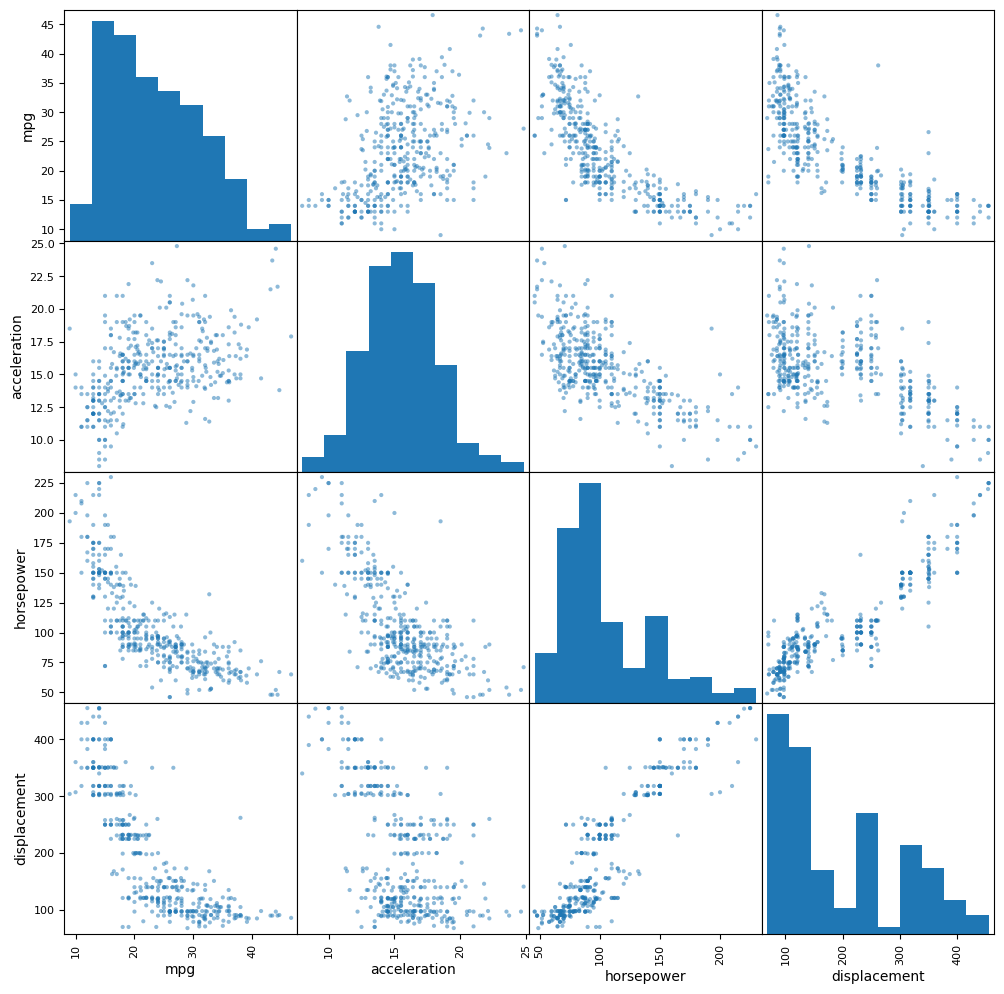

In [40]:
colunas = ['mpg', 'acceleration', 'horsepower', 'displacement']
pd.plotting.scatter_matrix(Auto[colunas], figsize=(12,12));

In [41]:
y = Auto['mpg']
X = Auto[['acceleration', 'horsepower', 'displacement']]
mpg_df = np.linspace(y.min(), y.max(), 100)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, random_state=42)

# Polynomial #

In [42]:
ms_accel_poly = [ModelSpec([poly('acceleration',degree=grau)]) for grau in range(1,11)]
X_accel_poly = [modelo.fit_transform(X_treino) for modelo in ms_accel_poly]
modelos_accel_poly = [OLS(y_treino, X_).fit() for X_ in X_accel_poly]
anova_lm(*modelos_accel_poly)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,292.0,15468.860723,0.0,NaN,NaN,NaN
1,291.0,15044.516679,1.0,424.344044,8.138991,0.004643
2,290.0,15044.370695,1.0,0.145984,0.002800,0.957836
3,289.0,14889.781037,1.0,154.589658,2.965056,0.086151
4,288.0,14862.888513,1.0,26.892524,0.515803,0.473220
5,287.0,14826.689396,1.0,36.199117,0.694305,0.405397
6,286.0,14826.596402,1.0,0.092994,0.001784,0.966342
7,285.0,14799.588321,1.0,27.008080,0.518020,0.472277
8,284.0,14760.847857,1.0,38.740465,0.743049,0.389413
9,283.0,14754.822143,1.0,6.025714,0.115574,0.734137


In [43]:
predicao_treino_accel = [modelo.predict(X_) for modelo, X_ in zip(modelos_accel_poly, X_accel_poly)]
mse_treino_accel = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_accel]
predicao_teste_accel = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_accel_poly, ms_accel_poly)]
mse_teste_accel = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_accel]

pd.DataFrame({'MSE_treino':mse_treino_accel, 'MSE_teste':mse_teste_accel})

,MSE_treino,MSE_teste
0,52.615173,41.985900
1,51.171825,43.104726
2,51.171329,43.164635
3,50.645514,40.647306
4,50.554043,40.737840
5,50.430916,40.605083
6,50.430600,40.587401
7,50.338736,40.664027
8,50.206965,40.152136
9,50.186470,40.550664


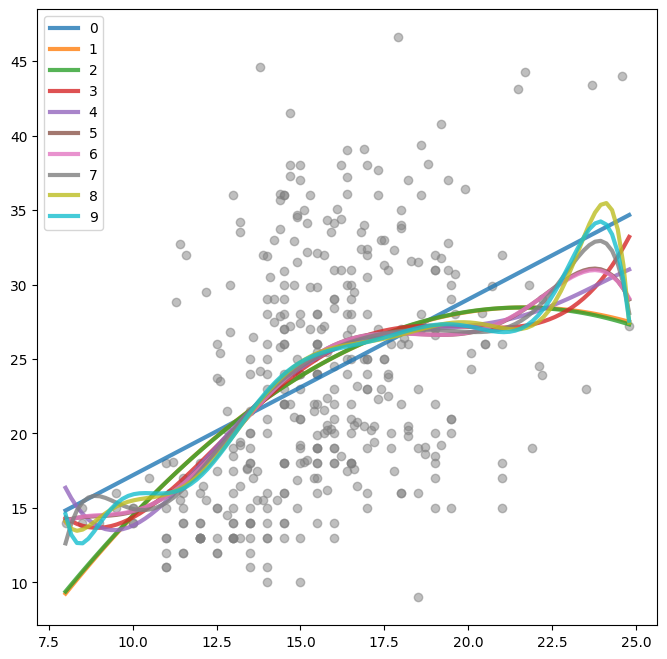

In [44]:
ax = subplots(figsize=(8,8))[1]
df_accel = pd.DataFrame({'acceleration':np.linspace(Auto['acceleration'].min(), Auto['acceleration'].max(),100)})
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for modelo, ms, i in zip(modelos_accel_poly, ms_accel_poly, range(0, 11)):
    ax.plot(df_accel.values, modelo.predict(ms.transform(df_accel)), alpha=0.8, linewidth=3, label=f'{i}')
ax.legend();

In [45]:
for coluna in ['acceleration', 'horsepower', 'displacement']:
    print(f'**********************{coluna}**********************')
    ms_poly = [ModelSpec([poly(coluna,degree=grau)]) for grau in range(1,11)]
    X_poly = [modelo.fit_transform(X_treino) for modelo in ms_poly]
    modelos_poly = [OLS(y_treino, X_).fit() for X_ in X_poly]
    print(anova_lm(*modelos_poly))
    predicao_treino = [modelo.predict(X_) for modelo, X_ in zip(modelos_poly, X_poly)]
    mse_treino = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino]
    predicao_teste = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_poly, ms_poly)]
    mse_teste = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste]
    print(pd.DataFrame({'MSE_treino':mse_treino, 'MSE_teste':mse_teste}))
    print(f'******************************************************\n')

**********************acceleration**********************
   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     292.0  15468.860723      0.0         NaN       NaN       NaN
1     291.0  15044.516679      1.0  424.344044  8.138991  0.004643
2     290.0  15044.370695      1.0    0.145984  0.002800  0.957836
3     289.0  14889.781037      1.0  154.589658  2.965056  0.086151
4     288.0  14862.888513      1.0   26.892524  0.515803  0.473220
5     287.0  14826.689396      1.0   36.199117  0.694305  0.405397
6     286.0  14826.596402      1.0    0.092994  0.001784  0.966342
7     285.0  14799.588321      1.0   27.008080  0.518020  0.472277
8     284.0  14760.847857      1.0   38.740465  0.743049  0.389413
9     283.0  14754.822143      1.0    6.025714  0.115574  0.734137
   MSE_treino  MSE_teste
0   52.615173  41.985900
1   51.171825  43.104726
2   51.171329  43.164635
3   50.645514  40.647306
4   50.554043  40.737840
5   50.430916  40.605083
6   50.430600  40.587401
7   50

# Step Functions #

In [46]:
X_treino_qcut = []
X_teste_qcut = []
faixas_qcut = []
modelos_qcut = []
for i in range(1,11):
    coluna = 'acceleration'
    X_, faixa_corte = pd.qcut(X_treino[coluna], i, retbins=True)
    faixas_qcut.append(faixa_corte)
    X_treino_qcut.append(pd.get_dummies(X_))
    X_teste_qcut.append(pd.get_dummies(pd.cut(X_teste[coluna], bins=faixa_corte)))
    modelos_qcut = [OLS(y_treino, X_).fit() for X_ in X_treino_qcut]

df_anova_qcut = anova_lm(*modelos_qcut)
df_anova_qcut

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,293.0,18805.232007,0.0,NaN,NaN,NaN
1,292.0,16888.384801,1.0,1916.847206,37.688593,2.702522e-09
2,291.0,15287.167092,1.0,1601.217709,31.482761,4.686044e-08
3,290.0,14951.644182,1.0,335.522910,6.596972,1.071586e-02
4,289.0,15148.225976,1.0,-196.581794,-3.865144,1.000000e+00
5,288.0,14925.211303,1.0,223.014673,4.384861,3.713353e-02
6,287.0,14785.838826,1.0,139.372477,2.740308,9.893889e-02
7,286.0,14604.318555,1.0,181.520271,3.569008,5.987896e-02
8,285.0,14490.173717,1.0,114.144838,2.244289,1.352153e-01
9,284.0,14444.280399,1.0,45.893318,0.902343,3.429618e-01


In [47]:
pd.DataFrame(faixas_qcut)

,0,1,2,3,4,5,6,7,8,9,10
0,8.0,24.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8.0,15.400000,24.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8.0,14.266667,16.500000,24.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8.0,13.500000,15.400000,17.300000,24.800000,NaN,NaN,NaN,NaN,NaN,NaN
4,8.0,13.200000,14.500000,16.000000,17.840000,24.800000,NaN,NaN,NaN,NaN,NaN
5,8.0,12.983333,14.266667,15.400000,16.500000,18.200000,24.8,NaN,NaN,NaN,NaN
6,8.0,12.500000,13.971429,14.857143,15.842857,17.000000,18.6,24.800,NaN,NaN,NaN
7,8.0,12.500000,13.500000,14.500000,15.400000,16.400000,17.3,18.875,24.80,NaN,NaN
8,8.0,12.055556,13.411111,14.266667,14.922222,15.777778,16.5,17.600,19.00,24.8,NaN
9,8.0,12.000000,13.200000,14.000000,14.500000,15.400000,16.0,16.900,17.84,19.0,24.8


In [48]:
pd.DataFrame([{'MSE_treino':mean_squared_error(y_treino,modelo.predict(X_)),
  'MSE_teste': mean_squared_error(y_teste, modelo.predict(X__))} for modelo, X_, X__ in zip(modelos_qcut, X_treino_qcut, X_teste_qcut)])

,MSE_treino,MSE_teste
0,63.963374,51.403404
1,57.443486,49.255251
2,51.997167,42.911388
3,50.855933,41.373315
4,51.524578,42.090617
5,50.766025,43.463267
6,50.291969,42.123546
7,49.674553,41.635138
8,49.286305,43.053346
9,49.130205,38.118906


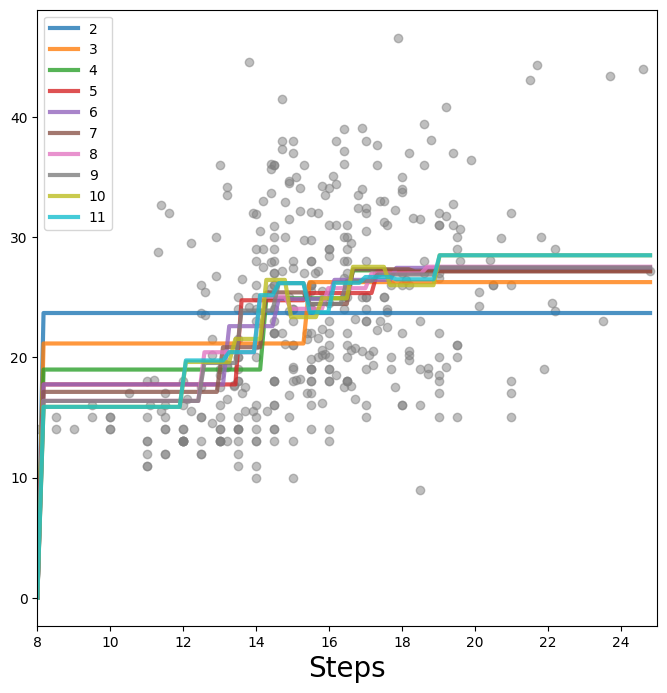

In [49]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for m, faixa in zip(modelos_qcut, faixas_qcut):
    ax.plot(df_accel.values, m.predict(pd.get_dummies(pd.cut(df_accel['acceleration'],bins=faixa))), alpha=0.8, linewidth=3, label=f'{len(faixa)}')
ax.set_xlabel('Steps', fontsize=20)
ax.set_xlim(8,25)
ax.legend();

In [50]:
def modelos_step_function(X_treino, y_treino, X_teste, y_teste, coluna, faixa_inicio=2, faixa_fim=11):
    X_treino_qcut = []
    X_teste_qcut = []
    faixas_qcut = []
    modelos_qcut = []
    for i in range(faixa_inicio, faixa_fim):
        X_, faixa_corte = pd.qcut(X_treino[coluna], i, retbins=True)
        faixas_qcut.append(faixa_corte)
        X_treino_qcut.append(pd.get_dummies(X_))
        X_teste_qcut.append(pd.get_dummies(pd.cut(X_teste[coluna], bins=faixa_corte)))
        modelos_qcut = [OLS(y_treino, X_).fit() for X_ in X_treino_qcut]

    df_anova_qcut = anova_lm(*modelos_qcut)
    df_faixas_qcut = pd.DataFrame(faixas_qcut)
    df_mse_qcut = pd.DataFrame([{'MSE_treino':mean_squared_error(y_treino,modelo.predict(X_)),
                'MSE_teste': mean_squared_error(y_teste, modelo.predict(X__))} for modelo, X_, X__ in zip(modelos_qcut, 
                                                                                                            X_treino_qcut, 
                                                                                                            X_teste_qcut)])
    return modelos_qcut, df_anova_qcut, df_faixas_qcut, df_mse_qcut


for coluna in ['acceleration', 'horsepower', 'displacement']:
    m, df_a, df_f, df_mse = modelos_step_function(X_treino, y_treino, X_teste, y_teste, coluna)
    print(f'************************{coluna}************************')
    print(df_a)
    print(df_mse)
    print(f'********************************************************\n')

************************acceleration************************
   df_resid           ssr  df_diff      ss_diff          F        Pr(>F)
0     292.0  16888.384801      0.0          NaN        NaN           NaN
1     291.0  15287.167092      1.0  1601.217709  31.482761  4.686044e-08
2     290.0  14951.644182      1.0   335.522910   6.596972  1.071586e-02
3     289.0  15148.225976      1.0  -196.581794  -3.865144  1.000000e+00
4     288.0  14925.211303      1.0   223.014673   4.384861  3.713353e-02
5     287.0  14785.838826      1.0   139.372477   2.740308  9.893889e-02
6     286.0  14604.318555      1.0   181.520271   3.569008  5.987896e-02
7     285.0  14490.173717      1.0   114.144838   2.244289  1.352153e-01
8     284.0  14444.280399      1.0    45.893318   0.902343  3.429618e-01
   MSE_treino  MSE_teste
0   57.443486  49.255251
1   51.997167  42.911388
2   50.855933  41.373315
3   51.524578  42.090617
4   50.766025  43.463267
5   50.291969  42.123546
6   49.674553  41.635138
7   49.28

# Splines #

In [51]:
modeleladores_spline = [ModelSpec([bs('acceleration', df=graus_liberdade)]) for graus_liberdade in range(3,9)]
X_treino_spline = [modelador.fit_transform(X_treino) for modelador in modeleladores_spline]
modelos_spline = [OLS(y_treino, X_).fit() for X_ in X_treino_spline]
anova_lm(*modelos_spline)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,290.0,15044.370695,0.0,NaN,NaN,NaN
1,289.0,14861.176427,1.0,183.194268,3.556682,0.060309
2,288.0,14844.153498,1.0,17.022929,0.330497,0.565815
3,287.0,14847.912036,1.0,-3.758538,-0.072971,1.000000
4,286.0,14714.838153,1.0,133.073883,2.583604,0.109079
5,285.0,14679.516465,1.0,35.321687,0.685764,0.408302


In [52]:
predicao_treino_splines = [modelo.predict(X_) for modelo, X_ in zip(modelos_spline, X_treino_spline)]
mse_treino_spline = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_splines]
predicao_teste_splines = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_spline, modeleladores_spline)]
mse_teste_spline = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_splines]

pd.DataFrame({'MSE_treino':mse_treino_spline, 'MSE_teste':mse_teste_spline})

,MSE_treino,MSE_teste
0,51.171329,43.164635
1,50.548219,40.407645
2,50.490318,40.578183
3,50.503102,40.419282
4,50.050470,40.108299
5,49.930328,40.471142


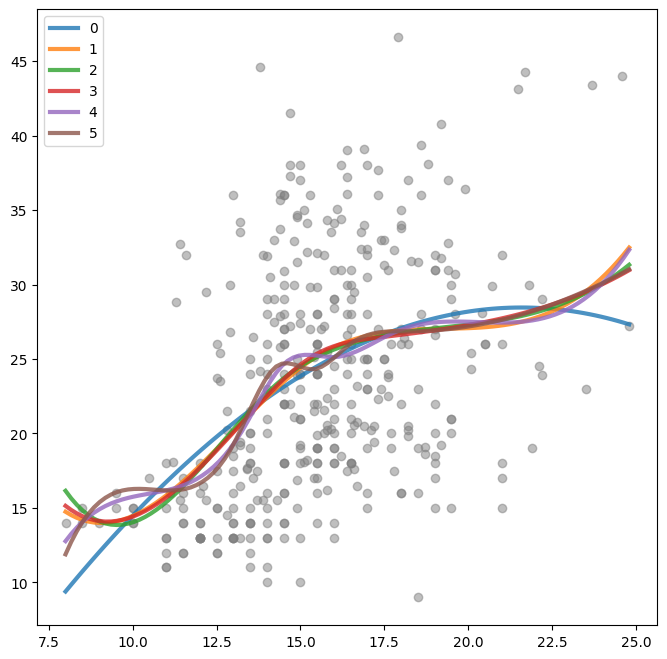

In [53]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for modelo, ms, i in zip(modelos_spline, modeleladores_spline, range(0, 11)):
    ax.plot(df_accel.values, modelo.predict(ms.transform(df_accel)), alpha=0.8, linewidth=3, label=f'{i}')
ax.legend();


In [54]:
int(np.ceil(4/3))

2

*****************************acceleration*****************************
   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     290.0  15044.370695      0.0         NaN       NaN       NaN
1     289.0  14861.176427      1.0  183.194268  3.558509  0.060243
2     288.0  14844.153498      1.0   17.022929  0.330667  0.565716
3     287.0  14847.912036      1.0   -3.758538 -0.073009  1.000000
4     286.0  14714.838153      1.0  133.073883  2.584931  0.108988
5     285.0  14679.516465      1.0   35.321687  0.686116  0.408182
6     284.0  14546.499913      1.0  133.016552  2.583818  0.109072
7     283.0  14494.375510      1.0   52.124402  1.012505  0.315163
8     282.0  14524.369824      1.0  -29.994313 -0.582633  1.000000
9     281.0  14466.055579      1.0   58.314245  1.132742  0.288105
   MSE_treino  MSE_teste
0   51.171329  43.164635
1   50.548219  40.407645
2   50.490318  40.578183
3   50.503102  40.419282
4   50.050470  40.108299
5   49.930328  40.471142
6   49.477891  40

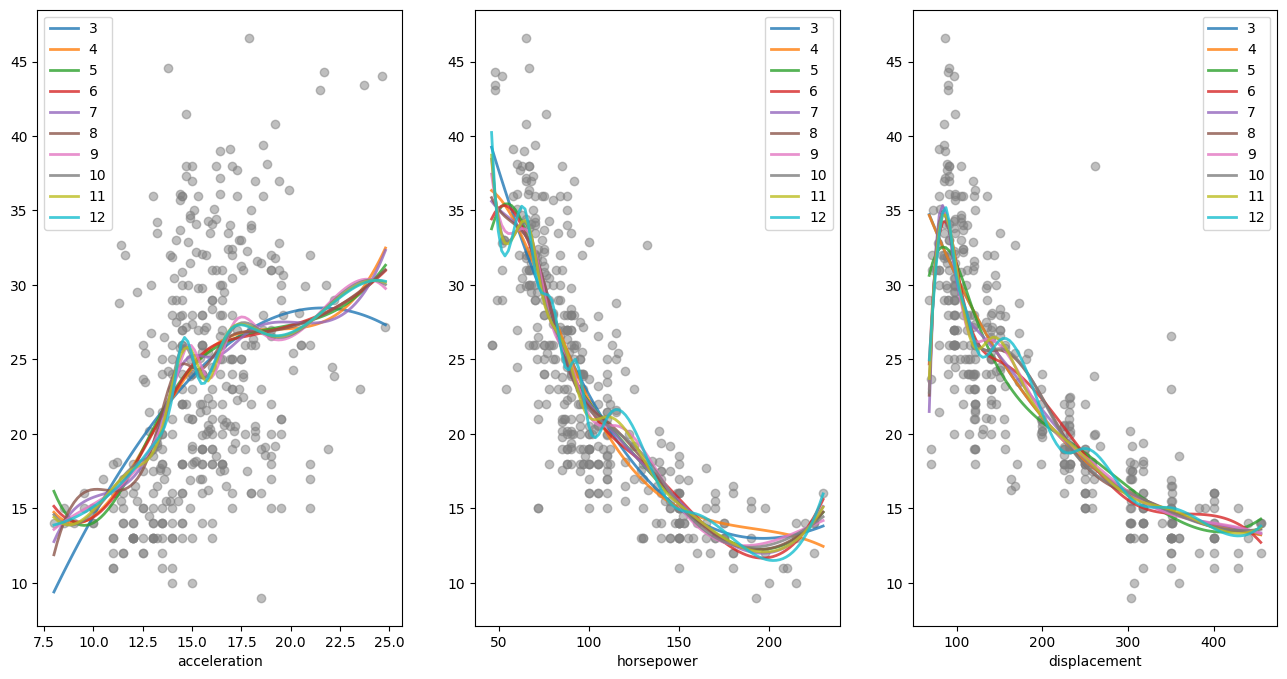

In [67]:
def modelos_splines(X_treino, y_treino, X_teste, y_teste, c_spline=bs, colunas = None, r_min=3, r_max=9 ):
    if colunas== None:
        colunas = X_treino.columns

    _, axes = subplots(int(np.ceil(len(colunas)/3)), 3, figsize=(16,8))
    axes = axes.flatten()
    for i, coluna in enumerate(colunas):
        print(f'*****************************{coluna}*****************************')
        
        modeleladores_spline = [ModelSpec([c_spline(coluna, df=graus_liberdade)]) for graus_liberdade in range(r_min, r_max)]
        X_treino_spline = [modelador.fit_transform(X_treino) for modelador in modeleladores_spline]
        modelos_spline = [OLS(y_treino, X_).fit() for X_ in X_treino_spline]
        print(anova_lm(*modelos_spline))
        predicao_treino_splines = [modelo.predict(X_) for modelo, X_ in zip(modelos_spline, X_treino_spline)]
        mse_treino_spline = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_splines]
        predicao_teste_splines = [ modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_spline, modeleladores_spline)]
        mse_teste_spline = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_splines]

        print(pd.DataFrame({'MSE_treino':mse_treino_spline, 'MSE_teste':mse_teste_spline}))

        ax = axes[i]
        ax.scatter(Auto[coluna], y, alpha=0.5, color='gray')
        _df = pd.DataFrame({f'{coluna}':np.linspace(Auto[coluna].min(), Auto[coluna].max(),100)})
        for modelo, ms, _i in zip(modelos_spline, modeleladores_spline, range(r_min, r_max)):
            ax.plot(_df.values, modelo.predict(ms.transform(_df)), alpha=0.8, linewidth=2, label=f'{_i}')
        ax.legend();
        ax.set_xlabel(coluna)

modelos_splines(X_treino, y_treino, X_teste, y_teste, r_max=13)

# Natural Splines #

In [56]:
modeleladores_naturalspline = [ModelSpec([ns('acceleration', df=graus_liberdade)]) for graus_liberdade in range(1,9)]
X_treino_naturalspline = [modelador.fit_transform(X_treino) for modelador in modeleladores_naturalspline]
modelos_naturalspline = [OLS(y_treino, X_).fit() for X_ in X_treino_naturalspline]
anova_lm(*modelos_naturalspline)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,292.0,15468.860723,0.0,NaN,NaN,NaN
1,291.0,14997.513971,1.0,471.346752,9.257742,0.002559
2,290.0,15000.072444,1.0,-2.558473,-0.050251,1.000000
3,289.0,14865.663725,1.0,134.408719,2.639927,0.105298
4,288.0,14755.576546,1.0,110.087179,2.162227,0.142531
5,287.0,14727.076550,1.0,28.499996,0.559770,0.454966
6,286.0,14564.601964,1.0,162.474586,3.191170,0.075096
7,285.0,14510.431534,1.0,54.170430,1.063964,0.303187


In [57]:
predicao_treino_naturalsplines = [modelo.predict(X_) for modelo, X_ in zip(modelos_naturalspline, X_treino_naturalspline)]
mse_treino_naturalspline = [mean_squared_error(y_treino, predicao) for predicao in predicao_treino_naturalsplines]
predicao_teste_naturalspline = [modelo.predict(ms.transform(X_teste)) for modelo, ms in zip(modelos_naturalspline, modeleladores_naturalspline)]
mse_teste_naturalspline = [mean_squared_error(y_teste, predicao) for predicao in predicao_teste_naturalspline]

pd.DataFrame({'MSE_treino':mse_treino_naturalspline, 'MSE_teste':mse_teste_naturalspline})

,MSE_treino,MSE_teste
0,52.615173,41.985900
1,51.011952,42.658071
2,51.020655,42.778851
3,50.563482,40.427875
4,50.189036,40.683080
5,50.092097,40.615166
6,49.539462,40.090292
7,49.355209,39.800824


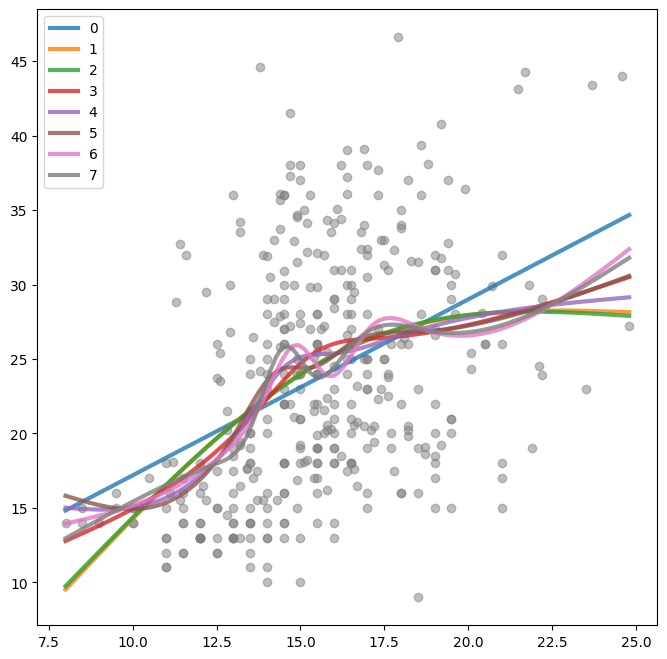

In [58]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(Auto['acceleration'], y, alpha=0.5, color='gray')
for modelo, ms, i in zip(modelos_naturalspline, modeleladores_naturalspline, range(0, 11)):
    ax.plot(df_accel.values, modelo.predict(ms.transform(df_accel)), alpha=0.8, linewidth=3, label=f'{i}')
ax.legend();

*****************************acceleration*****************************
   df_resid           ssr  df_diff     ss_diff         F    Pr(>F)
0     292.0  15468.860723      0.0         NaN       NaN       NaN
1     291.0  14997.513971      1.0  471.346752  9.219005  0.002612
2     290.0  15000.072444      1.0   -2.558473 -0.050041  1.000000
3     289.0  14865.663725      1.0  134.408719  2.628881  0.106026
4     288.0  14755.576546      1.0  110.087179  2.153180  0.143366
5     287.0  14727.076550      1.0   28.499996  0.557427  0.455910
6     286.0  14564.601964      1.0  162.474586  3.177818  0.075705
7     285.0  14510.431534      1.0   54.170430  1.059512  0.304199
8     284.0  14533.464212      1.0  -23.032677 -0.450493  1.000000
9     283.0  14469.145850      1.0   64.318362  1.257994  0.262982
   MSE_treino  MSE_teste
0   52.615173  41.985900
1   51.011952  42.658071
2   51.020655  42.778851
3   50.563482  40.427875
4   50.189036  40.683080
5   50.092097  40.615166
6   49.539462  40

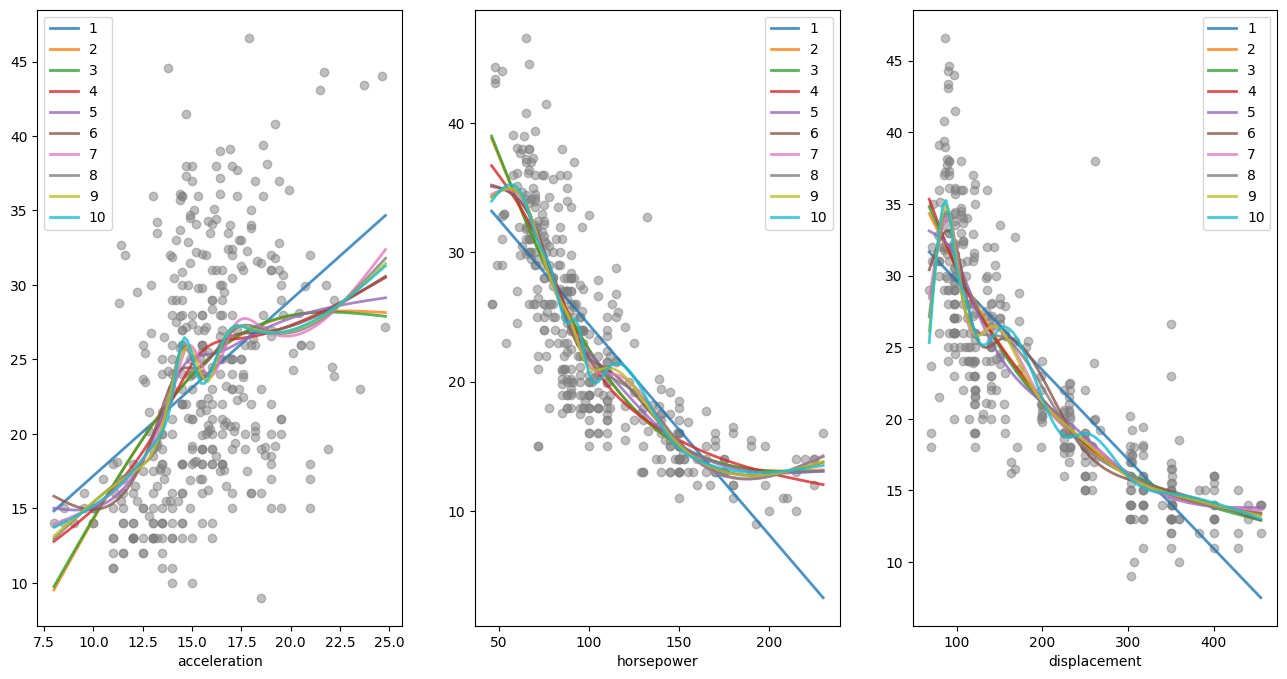

In [59]:
modelos_splines(X_treino, y_treino, X_teste, y_teste, ns, r_min=1, r_max=11)

# GAM #

In [60]:
#Calcular o MSE de um modelo linear para ser o modelo de comparação base

transformador_linear = ModelSpec(['acceleration', 'horsepower', 'displacement']).fit(X_treino)
modelo_linear = OLS(y_treino, transformador_linear.transform(X_treino))
resultado_linear = modelo_linear.fit()
mse_modelos = pd.DataFrame({'MSE_treino':[mean_squared_error(y_treino, resultado_linear.predict(transformador_linear.transform(X_treino)))],
                          'MSE_teste':[mean_squared_error(y_teste, resultado_linear.predict(transformador_linear.transform(X_teste)))]}, index=['linear'])
print(mse_modelos)
resultado_linear.summary()


        MSE_treino  MSE_teste
linear   19.781932   20.26267


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     215.9
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.42e-73
Time:                        16:15:21   Log-Likelihood:                -855.93
No. Observations:                 294   AIC:                             1720.
Df Residuals:                     290   BIC:                             1735.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       47.4224      2.937     16.149      0.000      41.643      53.202
acceleration    -0.4301      0.131     -3.278      0.001      -0.688      -0.172
horsepower      -0.0906      0.018     -4.994      0.000      -0.126      -0.055
displacement    -0.0389      0.006     -6.798      0.000      -0.050      -0.028
==============================================================================
Omnibus:                       36.977   Durbin-Watson:                   2.170
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               50.092
Skew:                           0.844   Prob(JB):                     1.33e-11
Kurtosis:                       4.113   Cond. No.                     2.78e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.78e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Não se pode considerar o modelo a seguir como um legítimo GAM pois não há o calculo da segunda derivada das funções dos preditores para penalizar a "rugosidade" das transformações, na idéia simples até podemos considerar, mas a nomenclatura correta é `Regression Splines` (Regressão por Splines)

In [61]:
accel_spline = BSpline(df=4).fit(X_treino['acceleration'])
horsepower_spline = BSpline(df=5).fit(X_treino['horsepower'])
displacement_spline = BSpline(df=6).fit(X_treino['displacement'])
X_treino_spline = np.hstack([accel_spline.transform(X_treino['acceleration']),
                             horsepower_spline.transform((X_treino['horsepower'])),
                             displacement_spline.transform(X_treino['displacement'])])
X_teste_spline = np.hstack([accel_spline.transform(X_teste['acceleration']),
                             horsepower_spline.transform((X_teste['horsepower'])),
                             displacement_spline.transform(X_teste['displacement'])])

X_treino_spline = add_constant(X_treino_spline, has_constant='add')
X_teste_spline = add_constant(X_teste_spline, has_constant='add') 


modelo_spline_gam = OLS(y_treino, X_treino_spline)
resultados_spline = modelo_spline_gam.fit()
mse_modelos.loc['regressao_spline_1'] = [
    mean_squared_error(y_treino, resultados_spline.predict(X_treino_spline)),
    mean_squared_error(y_teste, resultados_spline.predict(X_teste_spline))
]
print(mse_modelos)
resultado_linear.summary()

                    MSE_treino  MSE_teste
linear               19.781932  20.262670
regressao_spline_1   13.513727  14.579179


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.691
Model:                            OLS   Adj. R-squared:                  0.688
Method:                 Least Squares   F-statistic:                     215.9
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.42e-73
Time:                        16:15:22   Log-Likelihood:                -855.93
No. Observations:                 294   AIC:                             1720.
Df Residuals:                     290   BIC:                             1735.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept       47.4224      2.937     16.149      0.000      41.643      53.202
acceleration    -0.4301      0.131     -3.278      0.001      -0.688      -0.172
horsepower      -0.0906      0.018     -4.994      0.000      -0.126      -0.055
displacement    -0.0389      0.006     -6.798      0.000      -0.050      -0.028
==============================================================================
Omnibus:                       36.977   Durbin-Watson:                   2.170
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               50.092
Skew:                           0.844   Prob(JB):                     1.33e-11
Kurtosis:                       4.113   Cond. No.                     2.78e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.78e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [62]:
transformador_spline = ModelSpec([bs('acceleration', df=4), bs('horsepower',df=5), bs('displacement',df=6)]).fit(X_treino)
modelo_spline = OLS(y_treino, transformador_spline.transform(X_treino))
resultado_spline = modelo_spline.fit()

mse_modelos.loc['regressao_spline_2'] = [
    mean_squared_error(y_treino, resultado_spline.predict(transformador_spline.transform(X_treino))),
    mean_squared_error(y_teste, resultado_spline.predict(transformador_spline.transform(X_teste)))
]
print(mse_modelos)
resultado_spline.summary()

                    MSE_treino  MSE_teste
linear               19.781932  20.262670
regressao_spline_1   13.513727  14.579179
regressao_spline_2   13.513727  14.579179


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     69.19
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.66e-84
Time:                        16:15:22   Log-Likelihood:                -799.91
No. Observations:                 294   AIC:                             1632.
Df Residuals:                     278   BIC:                             1691.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
intercept                    35.7636      4.059      8.812      0.000      27.774      43.753
bs(acceleration, df=4)[0]     1.1970      3.848      0.311      0.756      -6.377       8.771
bs(acceleration, df=4)[1]    -5.0066      3.258     -1.537      0.126     -11.420       1.407
bs(acceleration, df=4)[2]    -4.2970      3.889     -1.105      0.270     -11.952       3.358
bs(acceleration, df=4)[3]    -7.4953      3.975     -1.885      0.060     -15.321       0.330
bs(horsepower, df=5)[0]       2.1461      2.910      0.738      0.461      -3.582       7.874
bs(horsepower, df=5)[1]      -9.1475      2.332     -3.922      0.000     -13.739      -4.556
bs(horsepower, df=5)[2]     -11.2749      3.637     -3.100      0.002     -18.434      -4.116
bs(horsepower, df=5)[3]     -23.2360      4.550     -5.107      0.000     -32.193     -14.279
bs(horsepower, df=5)[4]     -14.9505      4.348     -3.439      0.001     -23.510      -6.391
bs(displacement, df=6)[0]     6.0901      2.556      2.383      0.018       1.058      11.122
bs(displacement, df=6)[1]     1.5102      1.821      0.829      0.408      -2.075       5.096
bs(displacement, df=6)[2]     0.3571      2.435      0.147      0.884      -4.437       5.151
bs(displacement, df=6)[3]    -8.9251      2.761     -3.233      0.001     -14.360      -3.490
bs(displacement, df=6)[4]    -1.1706      3.438     -0.341      0.734      -7.938       5.596
bs(displacement, df=6)[5]    -6.9006      3.801     -1.815      0.071     -14.383       0.582
==============================================================================
Omnibus:                       47.708   Durbin-Watson:                   1.958
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.963
Skew:                           0.799   Prob(JB):                     3.60e-24
Kurtosis:                       5.502   Cond. No.                         46.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [63]:
modelo_gam = LinearGAM(s_gam(0, n_splines=4) + s_gam(1, n_splines=5) + s_gam(2, n_splines=6))
modelo_gam.fit(X_treino, y_treino)
mse_modelos.loc['splines_GAM'] = [
    mean_squared_error(y_treino, modelo_gam.predict(X_treino)), 
    mean_squared_error(y_teste, modelo_gam.predict(X_teste))]
print(mse_modelos)
modelo_gam.summary()

                    MSE_treino  MSE_teste
linear               19.781932  20.262670
regressao_spline_1   13.513727  14.579179
regressao_spline_2   13.513727  14.579179
splines_GAM          14.605303  16.110335
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      6.2836
Link Function:                     IdentityLink Log Likelihood:                                  -811.3655
Number of Samples:                          294 AIC:                                             1637.2983
                                                AICc:                                            1637.7207
                                                GCV:                                               15.5202
                                         

C:\Users\olive\AppData\Local\Temp\ipykernel_8676\2593796807.py:7: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  modelo_gam.summary()


In [64]:
modelo_gam = LinearGAM(s_gam(0, n_splines=10) + s_gam(1, n_splines=9) + s_gam(2, n_splines=10))

grade_lam = np.logspace(-4, 4, 21)
lams_grid = [grade_lam] * 3

modelo_gam.gridsearch(X_treino.values, y_treino.values, lam=lams_grid)

mse_modelos.loc['splines_GAM_otimizado'] = [
    mean_squared_error(y_treino, modelo_gam.predict(X_treino)), 
    mean_squared_error(y_teste, modelo_gam.predict(X_teste))
]

print(mse_modelos)
modelo_gam.summary()


  0% (0 of 9261) |                       | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (4 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:04:47
  0% (8 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:04:40
  0% (12 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:04:27
  0% (16 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:05:32
  0% (21 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:05:08
  0% (25 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:05:05
  0% (30 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:04:53
  0% (34 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:04:47
  0% (40 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:04:27
  0% (44 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:04:28
  0% (48 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:04:27
  0% (52 of 9261) |                     

                       MSE_treino  MSE_teste
linear                  19.781932  20.262670
regressao_spline_1      13.513727  14.579179
regressao_spline_2      13.513727  14.579179
splines_GAM             14.605303  16.110335
splines_GAM_otimizado   14.135862  15.676477
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6992
Link Function:                     IdentityLink Log Likelihood:                                  -806.5803
Number of Samples:                          294 AIC:                                              1630.559
                                                AICc:                                            1631.1526
                                                GCV:                                    

C:\Users\olive\AppData\Local\Temp\ipykernel_8676\1196025312.py:14: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  modelo_gam.summary()


In [65]:
# Gruas de Liberdade Maiores
modelo_gam = LinearGAM(s_gam(0, n_splines=50) + s_gam(1, n_splines=50) + s_gam(2, n_splines=50))
grade_lam = np.logspace(-4, 4, 21)
lams_grid = [grade_lam] * 3

modelo_gam.gridsearch(X_treino.values, y_treino.values, lam=lams_grid)

mse_modelos.loc['splines_GAM_GS'] = [
    mean_squared_error(y_treino, modelo_gam.predict(X_treino)), 
    mean_squared_error(y_teste, modelo_gam.predict(X_teste))
]

print(mse_modelos)
modelo_gam.summary()


  0% (0 of 9261) |                       | Elapsed Time: 0:00:00 ETA:  --:--:--
  0% (1 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:30:57
  0% (3 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:17:48
  0% (5 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:14:18
  0% (7 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:13:01
  0% (9 of 9261) |                       | Elapsed Time: 0:00:00 ETA:   0:12:09
  0% (11 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:11:38
  0% (13 of 9261) |                      | Elapsed Time: 0:00:00 ETA:   0:11:15
  0% (15 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:10:56
  0% (17 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:10:39
  0% (19 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:10:32
  0% (21 of 9261) |                      | Elapsed Time: 0:00:01 ETA:   0:10:18
  0% (23 of 9261) |                     

                       MSE_treino  MSE_teste
linear                  19.781932  20.262670
regressao_spline_1      13.513727  14.579179
regressao_spline_2      13.513727  14.579179
splines_GAM             14.605303  16.110335
splines_GAM_otimizado   14.135862  15.676477
splines_GAM_GS          12.085359  16.010692
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      23.404
Link Function:                     IdentityLink Log Likelihood:                                  -783.9832
Number of Samples:                          294 AIC:                                             1616.7745
                                                AICc:                                            1621.3908
                                           

C:\Users\olive\AppData\Local\Temp\ipykernel_8676\2050381719.py:14: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  modelo_gam.summary()


In [66]:
mse_modelos.sort_values(by='MSE_teste')

,MSE_treino,MSE_teste
regressao_spline_1,13.513727,14.579179
regressao_spline_2,13.513727,14.579179
splines_GAM_otimizado,14.135862,15.676477
splines_GAM_GS,12.085359,16.010692
splines_GAM,14.605303,16.110335
linear,19.781932,20.262670


Todos os modelos explorados foram melhor que o linear isso mostra que y não pode ser bem explicado na forma de `Regrassão Linear`. Os modelos de `Regressão por Splines` tiveram o melhor desempenho final. 

Busquei em cada preditor utilizar uma técnica de flexibilização para no final montar o melhor GAM, neste cenário todos os preditores tiveram o melhor desempenho com o Spline, utilizei o melhor grau de liberdade para cada preditor a partir dessas análises, formando o modelo final.

Utilizando o grid search para encontrar o melhor lambda e estrapolando muito os graus de liberdade até chegou o no melhor resultado de treino porém não conseguiu generalizar, claramente resultando em um overfitting.

In [ ]:
df_modelo_GS = pd.DataFrame({'MSE_treino':[mean_squared_error(y_treino, resultado_linear.predict(transformador_linear.transform(X_treino)))],
                          'MSE_teste':[mean_squared_error(y_teste, resultado_linear.predict(transformador_linear.transform(X_teste)))]}, index=['linear'])
for grau in range(4,51):
    modelo_gam = LinearGAM(s_gam(0, n_splines=grau) + s_gam(1, n_splines=grau) + s_gam(2, n_splines=grau))
    grade_lam = np.logspace(-4, 4, 6)
    lams_grid = [grade_lam] * 3

    modelo_gam.gridsearch(X_treino.values, y_treino.values, lam=lams_grid, progress=False)
    
    df_modelo_GS.loc[f'grau_liberdade_{grau}'] = [
        mean_squared_error(y_treino, modelo_gam.predict(X_treino)), 
        mean_squared_error(y_teste, modelo_gam.predict(X_teste))
    ]


In [83]:
df_modelo_GS

,MSE_treino,MSE_teste
linear,19.781932,20.262670
grau_liberdade_4,14.424360,16.025726
grau_liberdade_5,14.242532,15.865177
grau_liberdade_6,14.443048,15.637412
grau_liberdade_7,14.127540,15.631245
grau_liberdade_8,14.354091,15.807221
grau_liberdade_9,14.226037,15.763096
grau_liberdade_10,14.099337,15.696315
grau_liberdade_11,13.991910,15.655551
grau_liberdade_12,13.912598,15.628366
